In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from region import Region
from functions import Functions
pfns = PlottingFns()
fns = Functions()

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
from cartopy.feature import LAND
from gsw import conversions, density
from glob import glob


In [4]:
f140 = '../data/SOSE/Adelie_140E_*.nc'
f145 = '../data/SOSE/Adelie_145E_*.nc'

In [5]:
ds140 = xr.open_mfdataset(glob(f140))
ds145 = xr.open_mfdataset(glob(f145))

In [6]:
gyre_index = xr.open_dataarray('gyre_index.nc')
sla_ = SLA(deg=0.25).da


In [7]:
extent_ac = [138,152,-68,-63]
extent_gyre = [145,150,-66.5,-65.5]
extent_ea=[60,160,-70,-60]

region_ac = Region('AC',extent_ac)
sla = region_ac.crop_da(sla_)

# filter dodgy sla signal
lonboo = sla.longitude < 147
latboo = sla.latitude > -66.6
sla = sla.where(lonboo | latboo,drop=True)

u,v = fns.get_geostrophic_currents(sla)
geos = xr.Dataset({'u10':u,'v10':v})

In [8]:
# chop and resample SOSE
ds = ds145.sel(YC = slice(-67.5,-65)).sel(YG = slice(-67.5,-65))
ds = ds.resample({'time':'MS'}).mean()

In [9]:
ds.load()

<xarray.Dataset> Size: 5MB
Dimensions:  (YC: 38, YG: 37, Z: 52, Zu: 52, Zl: 52, Zp1: 53, time: 132)
Coordinates: (12/22)
    XC       float64 8B 144.9
    XG       float64 8B 145.0
  * YC       (YC) float64 304B -67.49 -67.42 -67.36 ... -65.15 -65.08 -65.01
  * YG       (YG) float64 296B -67.46 -67.39 -67.33 ... -65.18 -65.11 -65.04
  * Z        (Z) float64 416B -2.1 -6.7 -12.15 ... -5e+03 -5.4e+03 -5.8e+03
  * Zu       (Zu) int64 416B 0 1 2 3 4 5 6 7 8 9 ... 43 44 45 46 47 48 49 50 51
    ...       ...
    drC      (Zp1) float64 424B 2.1 4.6 5.45 6.4 7.7 ... 400.0 400.0 400.0 200.0
    drF      (Z) float64 416B 4.2 5.0 5.9 6.9 8.5 ... 400.0 400.0 400.0 400.0
    hFacC    (Z, YC) float64 16kB 0.0 0.0 0.0 1.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
    hFacW    (Z, YC) float64 16kB 0.0 0.0 0.0 0.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
    hFacS    (Z, YG) float64 15kB 0.0 0.0 0.0 1.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
  * time     (time) datetime64[ns] 1kB 2013-01-01 2013-02-01 ... 2023-12-01
Data variables:
    THETA    (time, Z, YC) float32 1MB 0.0 0.0 0.0 -1.765 ... 0.0 0.0 0.0 0.0
    SALT     (time, Z, YC) float32 1MB 0.0 0.0 0.0 33.82 ... 0.0 0.0 0.0 0.0
    UVEL     (time, Z, YC) float32 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    VVEL     (time, Z, YG) float32 1MB 0.0 0.0 0.0 0.008925 ... 0.0 0.0 0.0 0.0
    WVEL     (time, Zl, YC) float32 1MB 0.0 0.0 0.0 -6.027e-07 ... 0.0 0.0 0.0
    ETAN     (time, YC) float32 20kB 0.0 0.0 0.0 -3.783 ... -1.804 -1.788 -1.786
    SIarea   (time, YC) float32 20kB 0.0 0.0 0.0 0.8482 ... 0.6152 0.6117 0.62
    SIheff   (time, YC) float32 20kB 0.0 0.0 0.0 2.234 ... 0.3674 0.356 0.3571
    PHIBOT   (time, YC) float32 20kB -2.135 -2.142 -2.149 ... -8.247 3.142 3.131
    BLGMLD   (time, YC) float32 20kB 4.2 4.2 4.2 18.79 ... 46.52 46.66 41.94

In [10]:
# compute density etc
ds['pressure'] = conversions.p_from_z(ds.Z,ds.YC.mean())
ds['asal'] = conversions.SA_from_SP(ds.SALT,ds.pressure,145,ds.YC).where(-ds.Z < ds.Depth,drop=True)
ds['ctemp'] = conversions.CT_from_t(ds.asal,ds.THETA,ds.pressure).where(-ds.Z < ds.Depth,drop=True)
ds['rho'] = density.rho(ds.asal,ds.ctemp,ds.pressure)
ds['sigma0'] = density.sigma0(ds.asal,ds.ctemp)

In [11]:
# prepare other data
sa_sla = fns.seasonal_anomaly(sla.sel(time=slice(ds.time[0],sla.time[-1])))
sa_geos = fns.seasonal_anomaly(geos.sel(time=slice(ds.time[0],sla.time[-1])))
sa_gyre = fns.seasonal_anomaly(gyre_index.sel(time=slice(ds.time[0],ds.time[-1])))
sa_sose = fns.seasonal_anomaly(ds)

ssn_gyre = fns.season_split(sa_gyre)
ssn_sla = fns.season_split(sa_sla)
ssn_geos = fns.season_split(sa_geos)
ssn_sose = fns.season_split(sa_sose)

(-1500.0, 0.0)

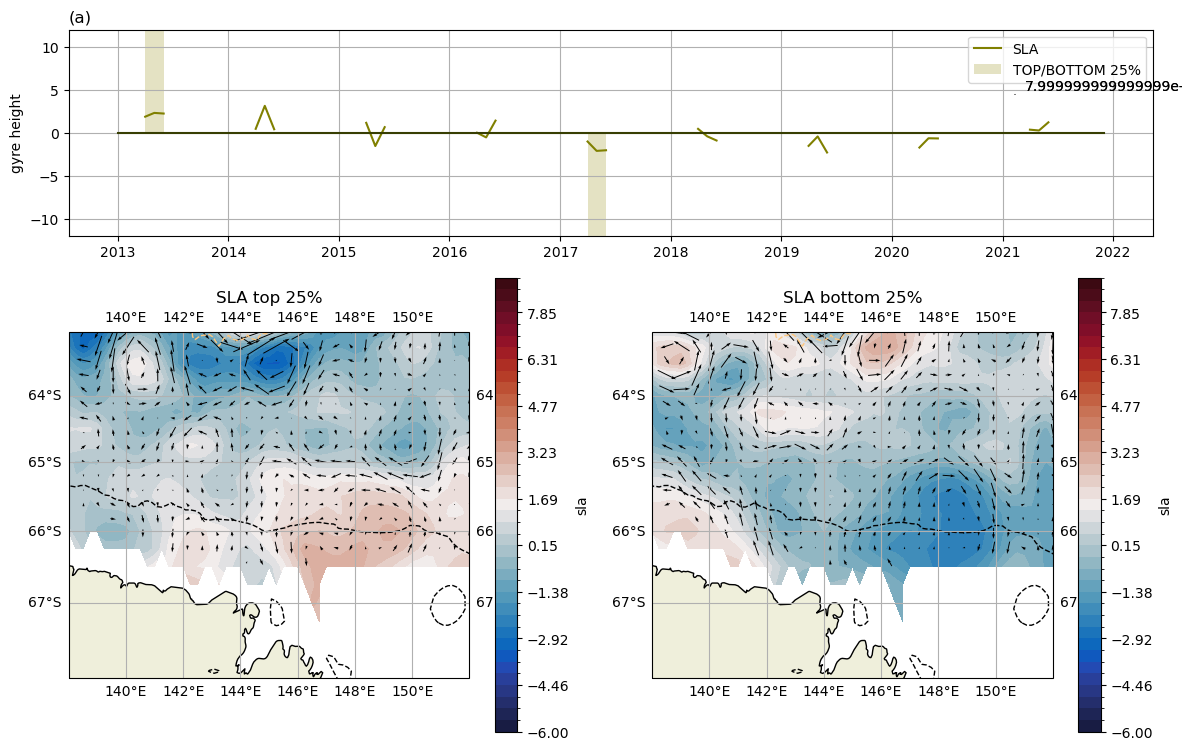

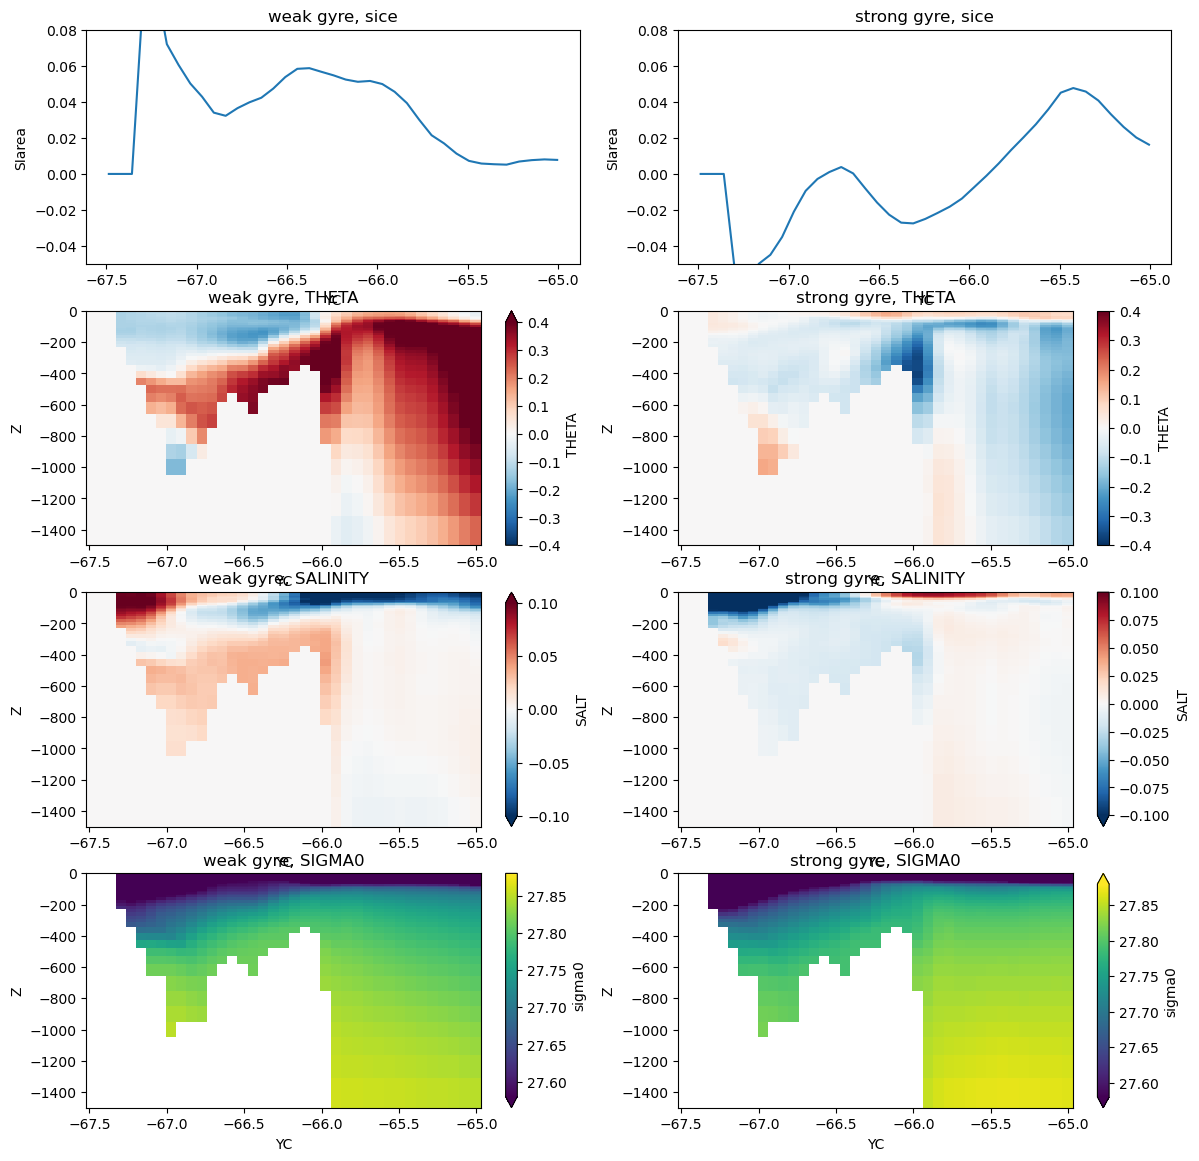

In [12]:
s = 'autumn'

topboo, botboo, top, bot = fns.get_topbot(ssn_gyre[s],0.25)
fns.run_for_idx(ssn_gyre[s],0.25,ssn_sla[s],ssn_geos[s],'SLA',extent_ac)

fig,axs = plt.subplots(4,2,figsize=(14,14))

z = -1500
ax = axs[0]
top(ssn_sose[s]).SIarea.plot(ax=ax[0])
ax[0].set_title('weak gyre, sice')
ax[0].set_ylim([-0.05,0.08])

bot(ssn_sose[s]).SIarea.plot(ax=ax[1])
ax[1].set_title('strong gyre, sice')
ax[1].set_ylim([-0.05,0.08])

ax = axs[1]
top(ssn_sose[s]).THETA.plot(ax=ax[0],vmin=-0.4)
ax[0].set_title('weak gyre, THETA')
ax[0].set_ylim([z,0])

bot(ssn_sose[s]).THETA.plot(ax=ax[1],vmin=-0.4)
ax[1].set_title('strong gyre, THETA')
ax[1].set_ylim([z,0])

ax = axs[2]
top(ssn_sose[s]).SALT.plot(ax=ax[0],vmin=-0.1)
ax[0].set_title('weak gyre, SALINITY')
ax[0].set_ylim([z,0])

bot(ssn_sose[s]).SALT.plot(ax=ax[1],vmin=-0.1)
ax[1].set_title('strong gyre, SALINITY')
ax[1].set_ylim([z,0])

ax = axs[3]
top(fns.season_split(ds)[s]).sigma0.plot(ax=ax[0],vmin=27.58,vmax=27.88)
ax[0].set_title('weak gyre, SIGMA0')
ax[0].set_ylim([z,0])

bot(fns.season_split(ds)[s]).sigma0.plot(ax=ax[1],vmin=27.58,vmax=27.88)
ax[1].set_title('strong gyre, SIGMA0')
ax[1].set_ylim([z,0])

In [13]:
ds['thetav'] = ds.THETA.interp({'YC':ds.YG})
ds['thetavvel'] = ds.thetav * ds.VVEL

In [14]:
xht = ds.thetavvel.integrate('Z')

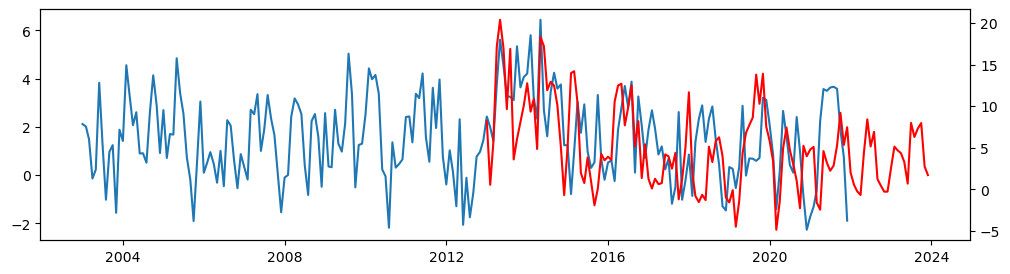

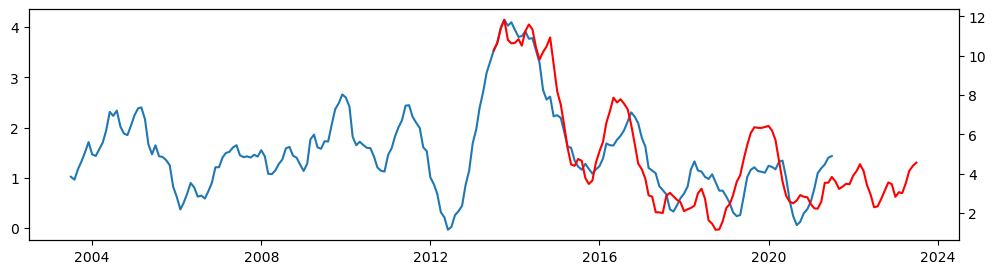

In [15]:
fig,ax = plt.subplots(figsize=(12,3))
ax.plot(gyre_index.time,gyre_index)
ax.twinx().plot(ds.time,ds.thetavvel.integrate('Z').mean('YG'),c='r')

fig,ax = plt.subplots(figsize=(12,3))
ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
ax.twinx().plot(ds.time,xht.mean('YG').rolling({'time':12},center=True).mean(),c='r')

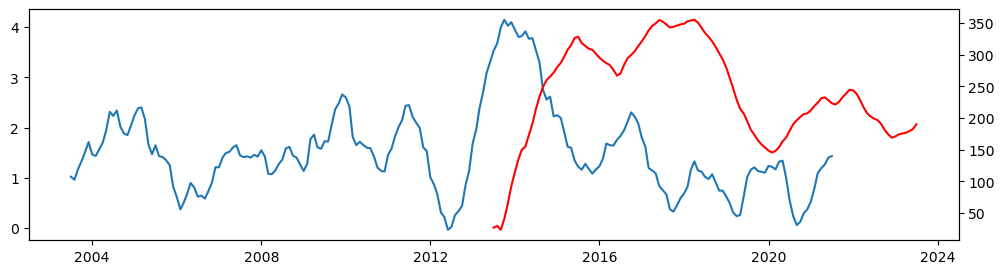

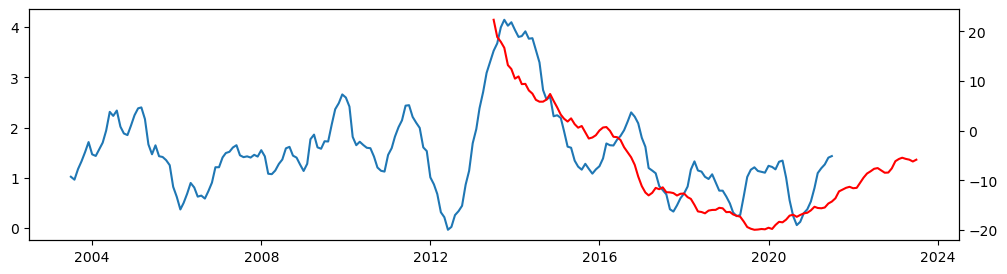

In [16]:

fig,ax = plt.subplots(figsize=(12,3))
ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
ax.twinx().plot(ds.time,ds.thetav.integrate('Z').mean('YG').rolling({'time':12},center=True).mean(),c='r')

fig,ax = plt.subplots(figsize=(12,3))
ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
ax.twinx().plot(ds.time,ds.VVEL.integrate('Z').mean('YG').rolling({'time':12},center=True).mean(),c='r')

In [17]:
s_sigma = fns.season_split(ds.sigma0)
s_theta = fns.season_split(ds.THETA)
s_salty = fns.season_split(ds.SALT)


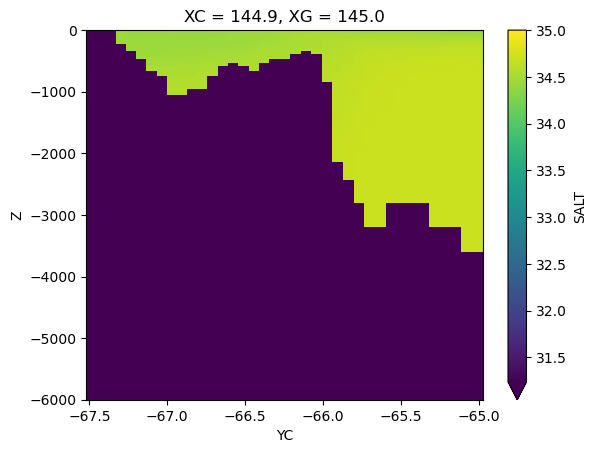

In [18]:
s_salty['spring'].mean('time').plot(vmin=35)

In [19]:
dss = fns.season_split(ds.sigma0)

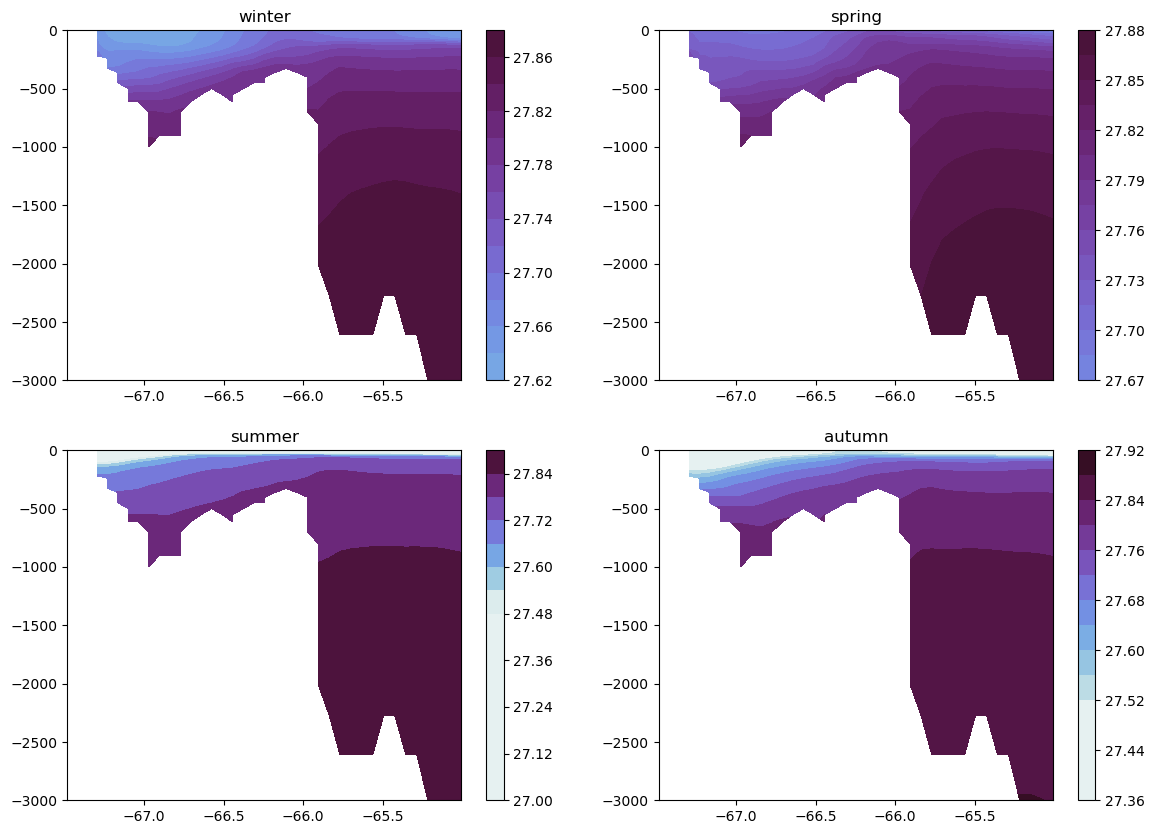

In [20]:
fig,axs = plt.subplots(2,2,figsize=(14,10))

def plotit(ax,s):
    im=ax.contourf(ds.YC,ds.Z,dss[s].mean('time'),vmax=27.9,vmin=27.5,levels=15,cmap=cmocean.cm.dense)
    ax.set_ylim([-3000,0])
    ax.set_title(s)
    plt.colorbar(im)

plotit(axs[0][0],'winter')
plotit(axs[0][1],'spring')
plotit(axs[1][0],'summer')
plotit(axs[1][1],'autumn')



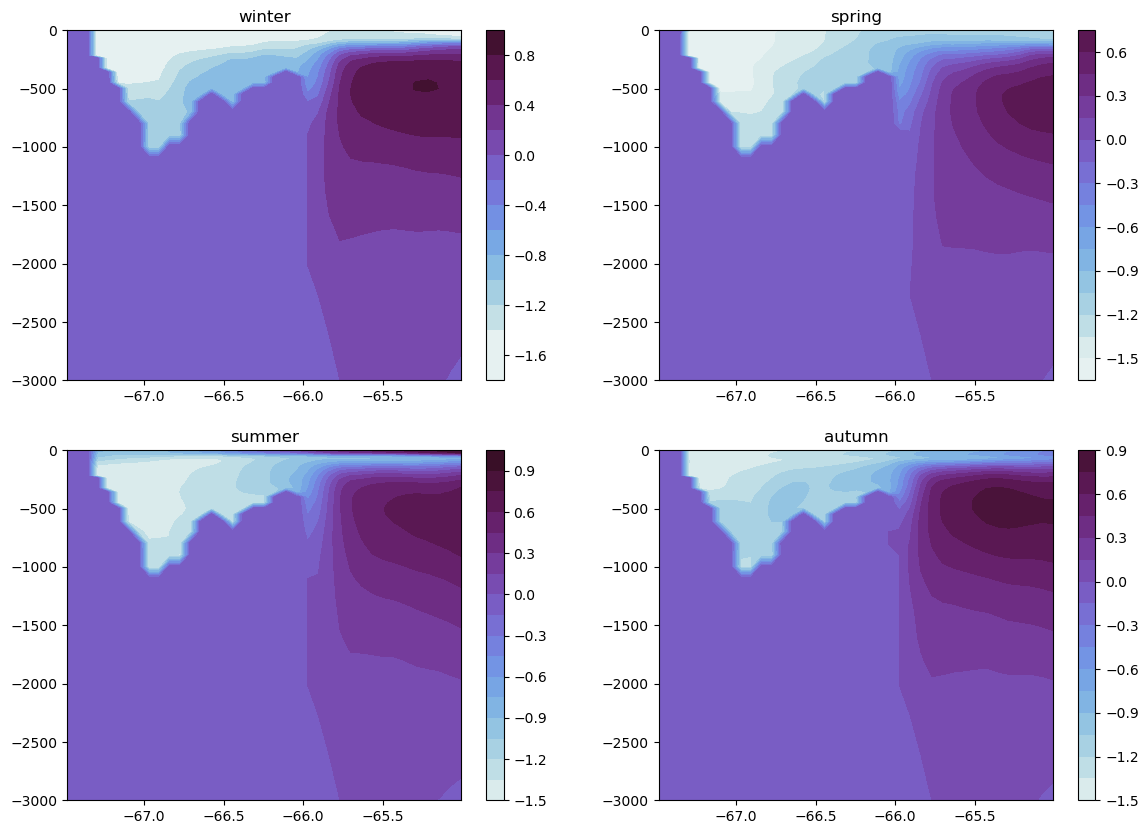

In [21]:
fig,axs = plt.subplots(2,2,figsize=(14,10))
dss = fns.season_split(ds.THETA)
def plotit(ax,s):
    im=ax.contourf(ds.YC,ds.Z,dss[s].mean('time'),vmax=1,vmin=-1.5,levels=15,cmap=cmocean.cm.dense)
    ax.set_ylim([-3000,0])
    ax.set_title(s)
    plt.colorbar(im)

plotit(axs[0][0],'winter')
plotit(axs[0][1],'spring')
plotit(axs[1][0],'summer')
plotit(axs[1][1],'autumn')

In [22]:
#LABEL water masstypes
ds['wmt'] = ds.sigma0 * np.nan

In [ ]:
ds['wmt'].where((ds.sigma0 > 27.7) & ,'mCDW')

<xarray.DataArray 'wmt' (time: 132, Z: 52, YC: 38)> Size: 2MB
array([[['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW'],
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW'],
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW'],
        ...,
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW'],
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW'],
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW']],

       [['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW'],
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW'],
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW'],
        ...,
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW'],
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW'],
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW']],

       [['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW'],
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW'],
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW'],
        ...,
...
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW'],
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW'],
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW']],

       [['mCDW', 'mCDW', 'mCDW', ..., nan, nan, nan],
        ['mCDW', 'mCDW', 'mCDW', ..., nan, nan, nan],
        ['mCDW', 'mCDW', 'mCDW', ..., nan, nan, nan],
        ...,
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW'],
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW'],
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW']],

       [['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW'],
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW'],
        ['mCDW', 'mCDW', 'mCDW', ..., nan, 'mCDW', 'mCDW'],
        ...,
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW'],
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW'],
        ['mCDW', 'mCDW', 'mCDW', ..., 'mCDW', 'mCDW', 'mCDW']]],
      dtype=object)
Coordinates: (12/13)
  * YC       (YC) float64 304B -67.49 -67.42 -67.36 ... -65.15 -65.08 -65.01
  * Z        (Z) float64 416B -2.1 -6.7 -12.15 ... -5e+03 -5.4e+03 -5.8e+03
  * time     (time) datetime64[ns] 1kB 2013-01-01 2013-02-01 ... 2023-12-01
    XC       float64 8B 144.9
    XG       float64 8B 145.0
    dxC      (YC) float64 304B 7.095e+03 7.114e+03 ... 7.809e+03 7.829e+03
    ...       ...
    rA       (YC) float64 304B 5.034e+07 5.061e+07 ... 6.098e+07 6.13e+07
    Depth    (YC) float64 304B 0.0 0.0 0.0 230.0 ... 3.176e+03 3.32e+03 3.32e+03
    rAw      (YC) float64 304B 5.034e+07 5.061e+07 ... 6.098e+07 6.13e+07
    drF      (Z) float64 416B 4.2 5.0 5.9 6.9 8.5 ... 400.0 400.0 400.0 400.0
    hFacC    (Z, YC) float64 16kB 0.0 0.0 0.0 1.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
    hFacW    (Z, YC) float64 16kB 0.0 0.0 0.0 0.0 1.0 ... 0.0 0.0 0.0 0.0 0.0